# Adversarial Attacks using API

## DPATCH Attack

In [1]:
import torch
import yolov5

from advsecurenet.models.model_factory import ModelFactory
from advsecurenet.datasets.dataset_factory import DatasetFactory
from advsecurenet.dataloader.data_loader_factory import DataLoaderFactory
from advsecurenet.shared.types.configs.preprocess_config import (
    PreprocessConfig,
    PreprocessStep,
)
from advsecurenet.shared.types.configs.device_config import DeviceConfig
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from advsecurenet.shared.types import DatasetType
from advsecurenet.models.CustomModels.CustomYolov5Model import CustomYolov5Model
from advsecurenet.models.CustomODWrappers.CustomYolov5ODWrapper import CustomYolov5ODWrapper
from advsecurenet.computer_vision.object_detection.attacks.adversarial_patch_based.dpatch import DPatchAttackConfig, DPatch

c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define the model
model = ModelFactory.create_model(
    model_name="CustomYolov5Model", 
    num_classes=10, 
    pretrained=False, 
    is_external=True,
    model_weights_path=None,
    model_arch_path="advsecurenet\models\CustomModels\CustomYolov5Model.py",
)

YOLOv5  2025-5-19 Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)



In [ ]:
clip_max = 255.0
preprocess_config = PreprocessConfig(steps=[
    PreprocessStep(name="Resize", params={"size": (640, 640)}),
    # 1. Turn a H×W×C numpy array (0–255) into a FloatTensor C×H×W in [0,1]
    PreprocessStep(name="ToTensor"),
    # 2. Cast dtype to float32 (some pipelines do this in ToTensor already,
    #    but this makes it explicit)
    PreprocessStep(name="ToDtype", params={"dtype": "torch.float32"}),
])
# Define the dataset
dataset = DatasetFactory.create_dataset(
    dataset_type=DatasetType.COCO, 
    preprocess_config=preprocess_config
)
test_data = dataset.load_dataset(train=False, download=True, root="/home/user/arutkiewicz/advsecurenet/code/advsecurenet_mp/advsecurenet/data/val2017-copy")

loading annotations into memory...
Done (t=0.43s)
creating index...
index created!


In [ ]:
# --------- temporary - reducing test_data to 2 samples for testing purposes ---------
from torch.utils.data import Subset

if 'test_data' in locals() and hasattr(test_data, '__len__') and hasattr(test_data, '__getitem__'):
    original_len = len(test_data)
    num_samples_to_keep = 5
    if original_len == 0:
        print("test_data is empty. Cannot create a subset.")
    elif original_len < num_samples_to_keep:
        print(f"test_data has only {original_len} sample(s), which is less than the desired {num_samples_to_keep}. Using all available {original_len} sample(s).")
    else:
        subset_indices = list(range(num_samples_to_keep))
        test_data = Subset(test_data, subset_indices)
        print(f"Reduced test_data from {original_len} to {len(test_data)} samples.")
else:
    print("Warning: 'test_data' for COCO dataset not found or is not a valid dataset. Please ensure it's loaded correctly in a previous cell.")
# ------------------------------------------------------------------------------------


Reduced test_data from 5000 to 5 samples.


In [5]:
def od_collate_fn(batch):
    """
    batch is list of (image_tensor, coco_annots_list)
    coco_annots_list: list of dicts with keys 'bbox' and 'category_id'
    """
    images = []
    boxes  = []
    labels = []
    scores = []

    for img, annots in batch:
        images.append(img)

        # turn COCO bboxes [x, y, w, h] → [x1, y1, x2, y2]
        img_boxes  = []
        img_labels = []
        img_scores = []
        for obj in annots:
            x, y, w, h = obj['bbox']
            img_boxes.append([x, y, x + w, y + h])
            img_labels.append(obj['category_id'])
            img_scores.append(1.0) # ground truth label
        if img_boxes:
            boxes.append(torch.tensor(img_boxes, dtype=torch.float32))
            scores.append(torch.tensor(img_scores, dtype=torch.float32))
            labels.append(torch.tensor(img_labels, dtype=torch.int64))
        else:
            # no objects in this image
            boxes.append(torch.zeros((0,4), dtype=torch.float32))
            scores.append(torch.zeros((0,), dtype=torch.float32))
            labels.append(torch.zeros((0,),   dtype=torch.int64))

    images = torch.stack(images, 0)  # (B, C, H, W)
    targets = {"boxes": boxes, "labels": labels, "scores": scores}
    return images, targets

dataloader = DataLoaderFactory.create_dataloader(dataset=test_data, batch_size=32, collate_fn=od_collate_fn, num_workers=0)

In [6]:
# model = yolov5.load('yolov5s.pt', device='cuda:0')
model = CustomYolov5Model(model_weights_path="model_weights\yolov5s.pt")
detector = CustomYolov5ODWrapper(model=model,
                        conf_thresh=0.25,
                        input_shape=(3, 640, 640),
                        clip_values=(0, 255), 
                        attack_losses=("loss_total", "loss_cls",
                                        "loss_box",
                                        "loss_obj"),
                        device_type='cuda:0')

# define the device config
device = DeviceConfig(processor="cuda:0")
config = DPatchAttackConfig(
    object_detector=detector,
    patch_shape=(3, 200, 200),
    learning_rate=1.99,
    max_iter=800,
    batch_size=16,
    verbose=True,
)
attack = DPatch(config)


YOLOv5  2025-5-19 Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)

YOLOv5  2025-5-19 Python-3.10.0 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)

Fusing layers... 
YOLOv5s summary: 270 layers, 7235389 parameters, 0 gradients, 16.6 GFLOPs
Adding AutoShape... 


### Option 1. Using the Attacker


In [7]:
from advsecurenet.computer_vision.object_detection.attacks.attacker import ODAttacker
from advsecurenet.shared.types.configs.attack_configs.od_attacker_config import (
    ODAttackerConfig,
)

attacker_config = ODAttackerConfig(
    model=model,
    attack=attack,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
    target_label=None,
)
attacker = ODAttacker(config=attacker_config)
adv_imgs = attacker.execute()

Generating adversarial samples:   0%|          | 0/1 [00:00<?, ?it/s]

Target label for attack:  None
[DPATCH] untargetted attack - true labels provided


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Training Step: %i 1


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\proj

...

DPatch iteration:  75%|███████▌  | 600/800 [02:15<00:39,  5.09it/s]c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\

Training Step: %i 700


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\proj

Training Step: %i 800


Generating adversarial samples: 100%|██████████| 1/1 [02:57<00:00, 177.41s/it]


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


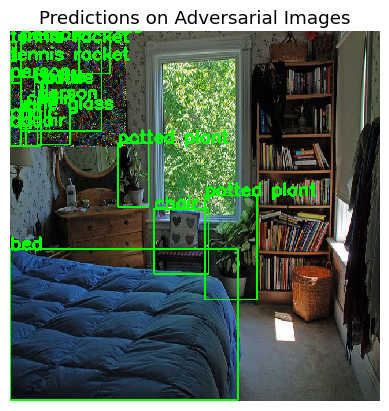

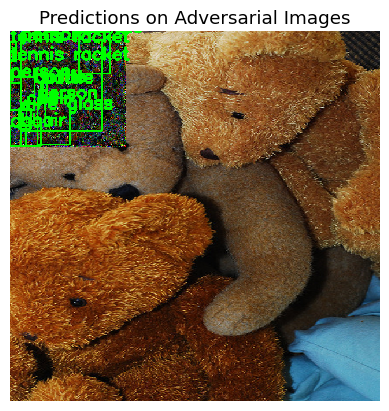

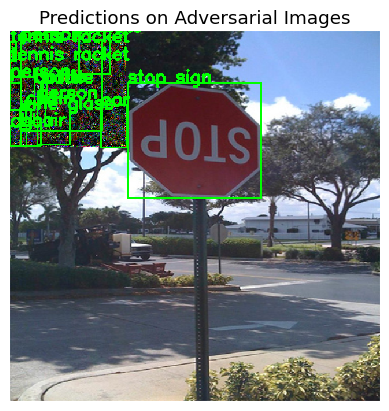

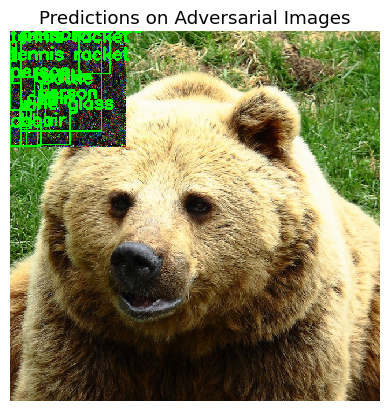

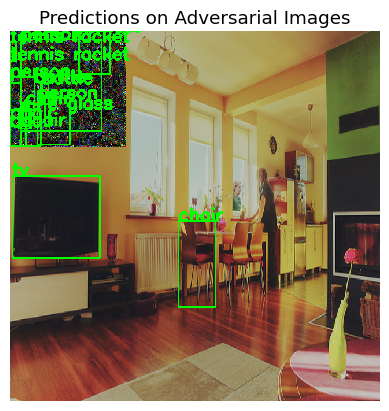

In [8]:
%matplotlib inline
import requests
from torchvision import transforms
import cv2
from advsecurenet.datasets.COCO.coco_utils import extract_predictions

def plot_image_with_boxes(img, boxes, pred_cls, title):
    text_size = 1
    text_th = 3
    rect_th = 2
    for i in range(len(boxes)):
        cv2.rectangle(img, (int(boxes[i][0][0]), int(boxes[i][0][1])), (int(boxes[i][1][0]), int(boxes[i][1][1])),
                      color=(0, 255, 0), thickness=rect_th)
        # Write the prediction class
        cv2.putText(img, pred_cls[i], (int(boxes[i][0][0]), int(boxes[i][0][1])), cv2.FONT_HERSHEY_SIMPLEX, text_size,
                    (0, 255, 0), thickness=text_th)
    plt.figure()
    plt.axis("off")
    plt.title(title)
    plt.imshow(img.astype(np.uint8), interpolation="nearest")
    plt.show()

# assume input_batch_np is N×H×W×C, dtype uint8 or float in [0,255]
import numpy as np
from PIL import Image

# assume each img_t is either [C,H,W] or [1,C,H,W], *normalized* with COCO mean/std
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

pil_imgs = []
if adv_imgs and len(adv_imgs[0]) > 0: # Check if adv_imgs[0] is not empty

    urls = ['http://images.cocodataset.org/val2017/000000039769.jpg',
    'http://images.cocodataset.org/val2017/000000397133.jpg',
    'http://images.cocodataset.org/val2017/000000037777.jpg',
    'http://images.cocodataset.org/val2017/000000454661.jpg',
    'http://images.cocodataset.org/val2017/000000094852.jpg']
    coco_images = []
    INPUT_SHAPE = (3, 640, 640)
    transform = transforms.Compose([
        transforms.Resize(INPUT_SHAPE[1], interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(INPUT_SHAPE[1]),
        transforms.ToTensor()
    ])
    for url in urls:
        im = Image.open(requests.get(url, stream=True).raw)
        im = transform(im).numpy()
        coco_images.append(im)
    coco_images = np.array(coco_images)

    coco_images = torch.from_numpy(coco_images).float()
    for img_t in adv_imgs[0]:
        # 1) squeeze to [C,H,W]

        if img_t.dim() == 4:
            img_t = img_t[0]
        # 2) to CPU numpy H×W×C
        arr = img_t.permute(1,2,0).cpu().numpy()
        # 3) denormalize back to [0,1] then to [0,255]
        # Assuming img_t was normalized with (img/255 - mean) / std
        # So, denormalize: (arr * std) + mean gives range [0,1] approx
        #arr = (arr * std + mean)
        arr = np.clip(arr*255, 0, 255).astype(np.uint8)
        # 4) convert to PIL
        pil_imgs.append(Image.fromarray(arr))
else:
    print("adv_imgs[0] is empty or adv_imgs is not populated correctly.")

imgs_np_hwc = [np.array(p) for p in pil_imgs]       # each shape (H,W,3)
if imgs_np_hwc: # Check if there are images to process
    imgs_np_nchw = np.stack([arr.transpose(2,0,1)     # (H,W,3) → (3,H,W)
                             for arr in imgs_np_hwc],
                            axis=0)
    dets = detector.predict(imgs_np_nchw)
    for img_nchw, det in zip(imgs_np_nchw, dets):
        cls, boxes, scores = extract_predictions(det, 0.7)
        img_hwc_display = img_nchw.transpose(1,2,0).copy()
        plot_image_with_boxes(img_hwc_display, boxes, cls, "Predictions on Adversarial Images")
else:
    print("No images processed to display.")

### Option 2. Manual Iteration

If you prefer to manually run the attack, you can loop through the dataloader to generate the adversarial samples. 

In [10]:
for batch_images_tensor, batch_targets_dict in tqdm(dataloader, desc="Attacking"):
    model_on_device = model.to(device.processor)
    batch_images_tensor = batch_images_tensor.to(device.processor)
    target_boxes_list_per_image = batch_targets_dict["boxes"]
    target_labels_list_per_image = batch_targets_dict["labels"]
    target_scores_list_per_image = batch_targets_dict["scores"]
    y_formatted_list = []
    num_images_in_batch = batch_images_tensor.shape[0] # Or len(target_boxes_list_per_image)
    for i in range(num_images_in_batch):
        # Move individual target tensors to the device
        img_boxes_tensor = target_boxes_list_per_image[i].cpu()
        img_labels_tensor = target_labels_list_per_image[i].cpu()
        img_scores_tensor = target_scores_list_per_image[i].cpu()
        y_formatted_list.append({
            "boxes": img_boxes_tensor,
            "labels": img_labels_tensor,
            "scores": img_scores_tensor,
        })
    adv_imgs = attack.attack(model=model_on_device, x=batch_images_tensor, target_label=None, y=y_formatted_list, mask=None)

Attacking:   0%|          | 0/1 [00:00<?, ?it/s]

[DPATCH] untargetted attack - true labels provided


c:\Users\rut30\OneDrive\Dokumenty\Desktop\UZH\SEMESTER_2\MASTER_PROJECT\project-code\advsecurenet_mp\.venv\lib\site-packages\yolov5\models\common.py:709: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Training Step: %i 1


Attacking:   0%|          | 0/1 [00:00<?, ?it/s]

⚠️ Invalid labels detected: [88 88 88 84 84 84 84 84 84 84 84 84 84 84 84 84 84 82 84 84 85 86 86 86 86] unique: [82 84 85 86 88]


ValueError: Found out-of-range labels in patch_target; see above.

In [ ]:
# for images, boxes, labels in tqdm(dataloader, desc="Attacking"):
#     model = model.to(device.processor)
#     images = images.to(device.processor)
#     boxes  = [b.to(device.processor) for b in boxes]
#     labels = [l.to(device.processor) for l in labels]
#     y = {
#       "boxes":  boxes,
#       "labels": labels,
#     }
#     adv_imgs = attack.attack(model=model, x=images, target_label=18, y=y, mask=None)

KeyboardInterrupt: 